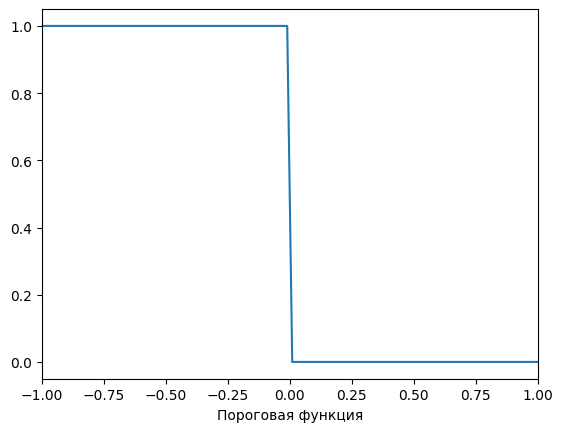

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def loss_function(x):
    return 0 if x > 0 else 1
data = np.linspace(-1, 1, 100)
loss = [loss_function(x) for x in data]

plt.xlabel('Пороговая функция')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.show()

In [3]:
#Примеры функции потерь на Python:

def exp_loss_func(x):
    return np.exp(-x)

def square_loss(x):
    return (1 - x) ** 2

def logistic_loss(x):
    return np.log2(1 + np.exp(-x))

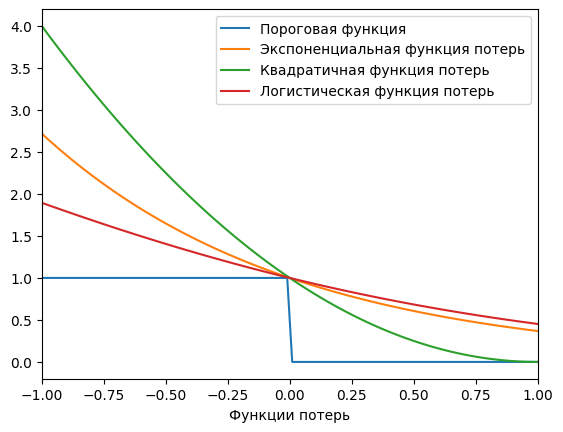

In [4]:
#И их визуализация:

exp_loss = [exp_loss_func(x) for x in data]
logistic_loss = [logistic_loss(x) for x in data]
square_loss = [square_loss(x) for x in data]

plt.xlabel('Функции потерь')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.plot(data, exp_loss)
plt.plot(data, square_loss)
plt.plot(data, logistic_loss)
plt.legend(['Пороговая функция', 'Экспоненциальная функция потерь', 'Квадратичная функция потерь', 'Логистическая функция потерь'])
plt.show()

In [5]:
#На языке Python данную функцию можно записать как:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

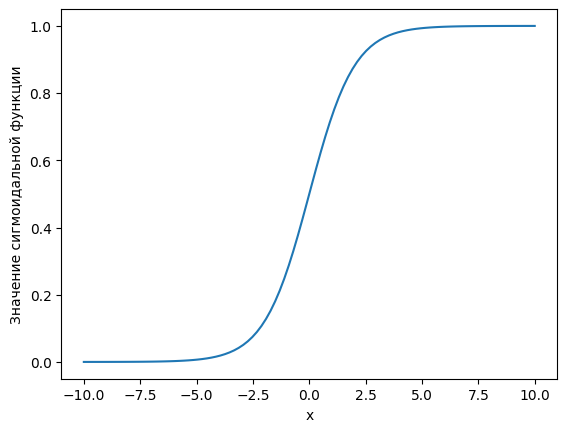

In [6]:
#Визуализируем ее:

data = np.linspace(-10, 10, 100)
sigmoid_value = list(map(sigmoid, data))

plt.xlabel('x')
plt.ylabel('Значение сигмоидальной функции')
plt.plot(data, sigmoid_value)
plt.show()#

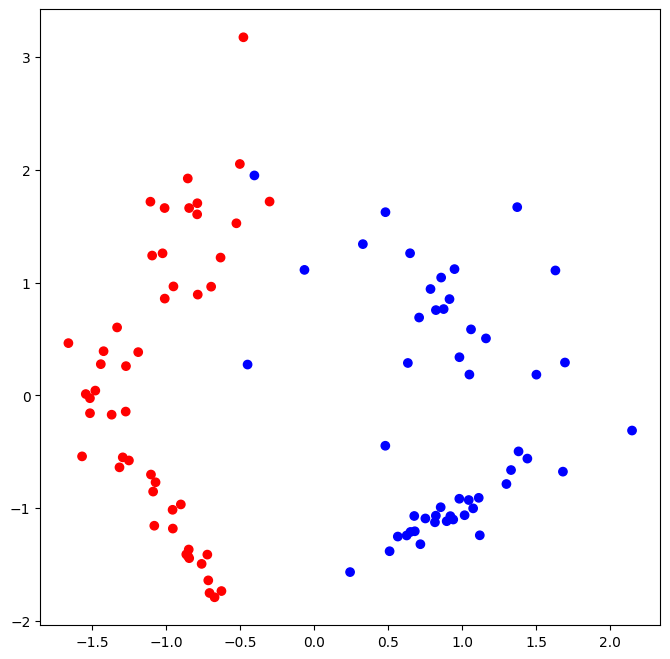

In [7]:
'''Решим задачу логистической регрессии, написав некоторый код на Python, с нуля реализующий алгоритм логистической регрессии.

Импортируем необходимые библиотеки и сгенерируем некоторый набор данных:'''

from sklearn import datasets
from matplotlib.colors import ListedColormap

# сгеренируем данные
classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1)

# и изобразим их на графике
colors = ListedColormap(['red', 'blue'])

plt.figure(figsize=(8, 8))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.show()

In [82]:
classes

(array([[ 1.30022717, -0.7856539 ],
        [ 1.44184425, -0.56008554],
        [-0.84792445, -1.36621324],
        [-0.72215015, -1.41129414],
        [-1.27221465,  0.25945106],
        [ 0.78694271,  0.94294879],
        [ 0.81695766, -1.12478707],
        [ 1.6822707 , -0.67596877],
        [-1.07223343, -0.7701513 ],
        [-0.06539297,  1.11257376],
        [-1.33232952,  0.60245671],
        [-0.6963714 ,  0.96382716],
        [ 0.82340614,  0.7561926 ],
        [-1.5155534 , -0.15804853],
        [-0.78971776,  1.70347973],
        [ 0.85887841,  1.04457966],
        [-0.45001335,  0.27345841],
        [ 0.7099324 ,  0.69020919],
        [-0.79095935,  1.60495551],
        [-1.08077536, -1.15530746],
        [-1.5691733 , -0.54054806],
        [-0.52568843,  1.52568161],
        [-1.27406042, -0.1434304 ],
        [ 0.89621114, -1.11509679],
        [-0.85259895, -1.42554982],
        [-0.63262806,  1.2217558 ],
        [-0.86447712, -1.40921978],
        [-0.47819102,  3.174

In [8]:
'''При работе с набором данных их рекомендуется перемешивать перед тем, как разделять на обучающую и тестовые выборки. Сделаем это:
'''
# перемешивание датасета
np.random.seed(12) # это число позволяет постоянно получать одну и ту же "случайность"
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

# разбивка на обучающую и тестовую выборки
train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

print("Размер массива признаков обучающей выборки", X_train.shape)
print("Размер массива признаков тестовой выборки", X_test.shape)
print("Размер массива ответов для обучающей выборки", y_train.shape)
print("Размер массива ответов для тестовой выборки", y_test.shape)

Размер массива признаков обучающей выборки (70, 2)
Размер массива признаков тестовой выборки (30, 2)
Размер массива ответов для обучающей выборки (70,)
Размер массива ответов для тестовой выборки (30,)


In [132]:
'''В предыдущем модуле вы уже изучали разделение исходного датасета на две подвыборки — 
тренировочную и тестовую — с помощью готового метода из библиотеки sklearn. 
Но в данном случае для пример разделили датасет вручную.

Далее транспонируем матрицы данных, так как нам удобнее работать со строками:
'''
X_train_tr = X_train.transpose()
y_train_tr = y_train.reshape(1, y_train.shape[0])
X_test_tr = X_test.transpose()
y_test_tr = y_test.reshape(1, y_test.shape[0])
y_train_tr.shape


(1, 70)

In [137]:
'''Теперь напишем скелеты функции, необходимые для обучения алгоритма логистической регрессии:'''

def log_loss(w, X, y):
    # здесь должны быть рассчитаны параметры градиента и значение функции потерь
    
    z = w.T @ X
    epsilon = 1e-15
    y_pred = 1 / (1 + np.exp(-z))

     
    loss = -np.mean(y * np.log(y_pred) + (1.0 - y_pred) * np.log(1.0 - y_pred))
    
    l = X.shape[1]
    grad = (X @ (y_pred - y).T) / l
    
   
    
    return loss, grad


def optimize(w, X, y, n_iterations, eta):
    # потери будем записывать в список для отображения в виде графика
    losses = []
    
    for i in range(n_iterations):
        loss, grad = log_loss(w, X, y)
        # считаем веса
        w = w - eta*grad
        losses.append(loss)

    return w, losses

def predict(w, X, b=0.5):
    z = w.T @ X
    y_pred = 1 / (1 + np.exp(-z))
    y_predicted = (y_pred > b).astype(int)
    # За порог отнесения к тому или иному классу примем вероятность 0.5

    return y_predicted

In [138]:
# инициализируем начальный вектор весов
w0 = np.zeros((X_train_tr.shape[0], 1))

n_iterations = 1000
eta = 0.05

w, losses = optimize(w0, X_train_tr, y_train_tr, n_iterations, eta)

y_predicted_test = predict(w, X_test_tr)
y_predicted_train = predict(w, X_train_tr)

# В качестве меры точности возьмем долю правильных ответов
train_accuracy = 100.0 - np.mean(np.abs(y_predicted_train - y_train_tr)*100.0)
test_accuracy = 100.0 - np.mean(np.abs(y_predicted_test-y_test_tr)*100.0)

print(f"Итоговый вектор весов w: {w}")
print(f"Точность на обучающей выборке: {train_accuracy:.3f}")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

Итоговый вектор весов w: [[3.72659902]
 [0.22383415]]
Точность на обучающей выборке: 98.571
Точность на тестовой выборке: 96.667


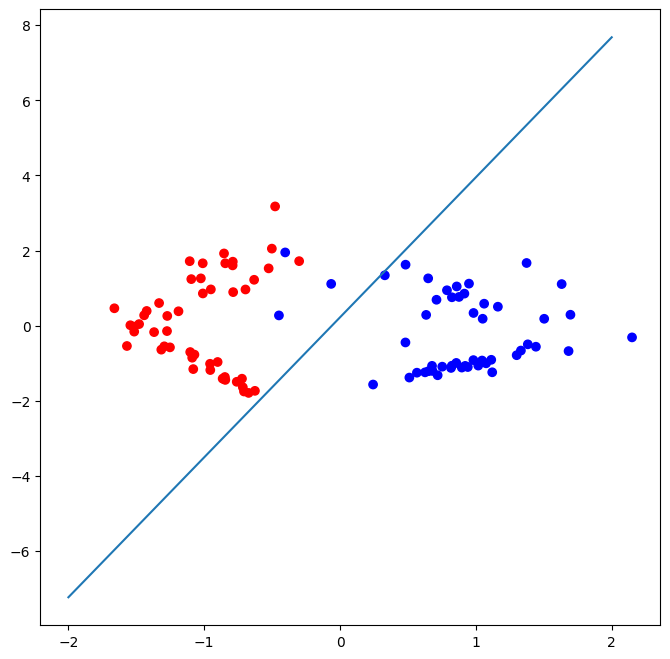

In [139]:
'''Визуализируем результат и функцию потерь:'''

data = np.linspace(-2, 2, 100)

plt.figure(figsize=(8, 8))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.plot(data, w[0,0]*data+w[1,0])

plt.show()

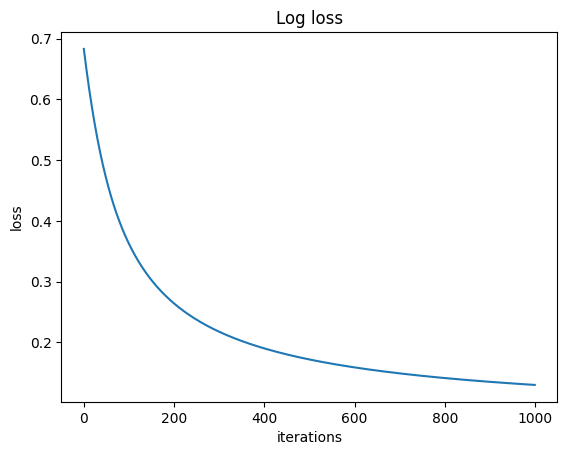

In [140]:
'''Визуализация функции потерь для данного примера:
'''
plt.title('Log loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.plot(range(len(losses)), losses)

plt.show()

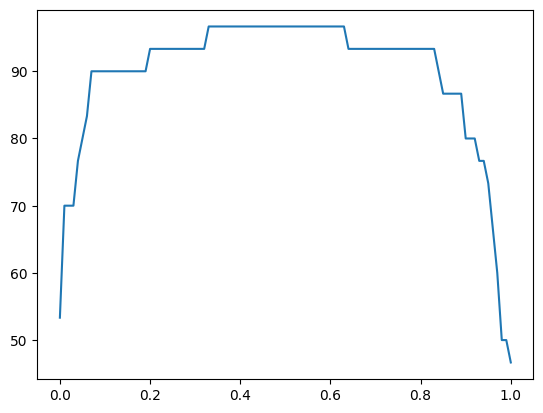

In [141]:
'''В завершение подберем различные значения порога для определения точности:'''

test_acc = []
b_l = []

for b in range(0, 101):
  y_predicted_test = predict(w, X_test_tr, b/100)
  y_predicted_train = predict(w, X_train_tr, b/100)

  # В качестве меры точности возьмем долю правильных ответов

  test_accuracy = 100.0 - np.mean(np.abs(y_predicted_test-y_test_tr)*100.0)

  b_l.append(b/100)
  test_acc.append(test_accuracy)

plt.plot(b_l, test_acc)
plt.show()

Работа с категориальными переменными

In [143]:
import pandas as pd

df = pd.read_csv(r"C:\IDE\2 семестр\Классическое МО\data\StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


Ручной метод

In [145]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [146]:
d = {'female': 0, 'male': 1}

# Заменим категориальные значения в столбце на числа
df['gender'] = df['gender'].map(d)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,none,72,72,74
1,0,group C,some college,standard,completed,69,90,88
2,0,group B,master's degree,standard,none,90,95,93
3,1,group A,associate's degree,free/reduced,none,47,57,44
4,1,group C,some college,standard,none,76,78,75


Кодирование с помощью готовых методов


In [148]:
from sklearn import preprocessing
# инициализация алгоритма кодирования
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(df['test preparation course'])
df['test preparation course'] = label_encoder.transform(df['test preparation course'])


In [149]:
df['test preparation course']

0      1
1      0
2      1
3      1
4      1
      ..
995    0
996    1
997    0
998    0
999    1
Name: test preparation course, Length: 1000, dtype: int64

In [150]:
df = pd.get_dummies(df, columns=['race/ethnicity'])

df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,bachelor's degree,standard,1,72,72,74,False,True,False,False,False
1,0,some college,standard,0,69,90,88,False,False,True,False,False
2,0,master's degree,standard,1,90,95,93,False,True,False,False,False
3,1,associate's degree,free/reduced,1,47,57,44,True,False,False,False,False
4,1,some college,standard,1,76,78,75,False,False,True,False,False


OneHotEncoder требует, чтобы данные были в формате двумерного массива (2D-array), поэтому сначала преобразуем столбец в двумерный массив, используя .values.reshape(-1, 1):

In [151]:
# 1. Инициализация алгоритма кодировщика
one_hot_encoder = preprocessing.OneHotEncoder()

# 2. Обучение алгоритма кодировщика
one_hot_encoder.fit(df['parental level of education'].values.reshape(-1, 1))
# 3. Применение модели кодировщика
x_new = one_hot_encoder.transform(df['parental level of education'].values.reshape(-1, 1)).toarray()

In [152]:
'''OneHotEncoder, в отличие от других кодировщиков, возвращает новый объект данных, который самостоятельно необходимо добавить после в исходный датасет:

'''# Получение названий новых столбцов
encoded_columns = one_hot_encoder.get_feature_names_out(['parental level of education'])

# Преобразование в DataFrame для удобства
encoded_df = pd.DataFrame(x_new, columns=encoded_columns)

# Объединение с исходным DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Удаление оригинального столбца (опционально)
df.drop(columns=['parental level of education'], inplace=True)

In [153]:
df= pd.DataFrame({
    'game': [
        'The Witcher 3', 
        'Minecraft', 
        'Overwatch', 
        'Dark Souls', 
        'Fortnite', 
        'Civilization VI', 
        'Stardew Valley', 
        'GTA V', 
        'League of Legends', 
        'Among Us'
    ],
    'genres': [
        'RPG,Action,Adventure',
        'Sandbox,Survival,Creative',
        'Shooter,Multiplayer,Action',
        'RPG,Action,Adventure',
        'Battle Royale,Shooter,Multiplayer',
        'Strategy,Simulation,Turn-Based',
        'Simulation,Farming,Indie',
        'Action,Adventure,Open World',
        'MOBA,Multiplayer,Strategy',
        'Social Deduction,Multiplayer,Indie'
    ]
})

df

,game,genres
0,The Witcher 3,"RPG,Action,Adventure"
1,Minecraft,"Sandbox,Survival,Creative"
2,Overwatch,"Shooter,Multiplayer,Action"
3,Dark Souls,"RPG,Action,Adventure"
4,Fortnite,"Battle Royale,Shooter,Multiplayer"
5,Civilization VI,"Strategy,Simulation,Turn-Based"
6,Stardew Valley,"Simulation,Farming,Indie"
7,GTA V,"Action,Adventure,Open World"
8,League of Legends,"MOBA,Multiplayer,Strategy"
9,Among Us,"Social Deduction,Multiplayer,Indie"


In [154]:
df['genres'].str.get_dummies(sep=',')

,Action,Adventure,Battle Royale,Creative,Farming,Indie,MOBA,Multiplayer,Open World,RPG,Sandbox,Shooter,Simulation,Social Deduction,Strategy,Survival,Turn-Based
0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1
6,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0
7,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0
9,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0


In [155]:
'''Теперь воспользуемся умным кодировщиком из библиотеки sklearn:'''

import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# Преобразование строки с категориями в список (list) из категорий
df['genres_split'] = df['genres'].str.split(',')

# Инициализация MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# Применение MultiLabelBinarizer к колонке 'genres'
genres_encoded = mlb.fit_transform(df['genres_split'])

# Создание нового DataFrame с закодированными жанрами
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

# Соединение с исходным DataFrame
df = pd.concat([df, genres_df], axis=1)

In [156]:
df

,game,genres,genres_split,Action,Adventure,Battle Royale,Creative,Farming,Indie,MOBA,Multiplayer,Open World,RPG,Sandbox,Shooter,Simulation,Social Deduction,Strategy,Survival,Turn-Based
0,The Witcher 3,"RPG,Action,Adventure","[RPG, Action, Adventure]",1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,Minecraft,"Sandbox,Survival,Creative","[Sandbox, Survival, Creative]",0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
2,Overwatch,"Shooter,Multiplayer,Action","[Shooter, Multiplayer, Action]",1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,Dark Souls,"RPG,Action,Adventure","[RPG, Action, Adventure]",1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,Fortnite,"Battle Royale,Shooter,Multiplayer","[Battle Royale, Shooter, Multiplayer]",0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0
5,Civilization VI,"Strategy,Simulation,Turn-Based","[Strategy, Simulation, Turn-Based]",0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1
6,Stardew Valley,"Simulation,Farming,Indie","[Simulation, Farming, Indie]",0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0
7,GTA V,"Action,Adventure,Open World","[Action, Adventure, Open World]",1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
8,League of Legends,"MOBA,Multiplayer,Strategy","[MOBA, Multiplayer, Strategy]",0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0
9,Among Us,"Social Deduction,Multiplayer,Indie","[Social Deduction, Multiplayer, Indie]",0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0


Логистическая регрессия (sklearn)

In [157]:
from sklearn.linear_model import LogisticRegression
df = pd.read_csv(r"C:\IDE\2 семестр\Классическое МО\data\StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [158]:
from sklearn.model_selection import train_test_split

# выделяем вектор признаков
X = df.drop(columns='gender')
# выделяем вектор целевой переменной
y = df['gender']

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [159]:
'''Так как большая часть переменных у нас представлена в виде категорий типа «строка», то сначала закодируем их:'''

from sklearn.preprocessing import OrdinalEncoder

categorical_features = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for column in categorical_features:
    label_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    # Обучаем на тренировочной подвыборке и сразу преобразовываем ее
    X_train[column] = label_encoder.fit_transform(X_train[column].values.reshape(-1, 1))
    
    # Преобразуем тестовую подвыборку с использованием того же обученного кодировщика
    X_test[column] = label_encoder.transform(X_test[column].values.reshape(-1, 1))

X_train

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
29,3.0,3.0,1.0,1.0,62,70,75
535,2.0,1.0,0.0,0.0,66,83,83
695,3.0,4.0,0.0,1.0,79,89,86
557,2.0,3.0,0.0,1.0,61,67,66
836,4.0,2.0,1.0,1.0,73,64,57
...,...,...,...,...,...,...,...
106,3.0,3.0,1.0,1.0,87,100,100
270,2.0,1.0,1.0,1.0,69,63,61
860,2.0,0.0,1.0,1.0,53,62,53
435,2.0,4.0,0.0,0.0,50,48,53


In [160]:
'''Теперь закодируем целевую переменную:'''

from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
'''Теперь создадим модель логистической регрессии и обучим ее на тренировочной подвыборке:'''

model = LogisticRegression()

model.fit(X_train, y_train)
'''Подскажем ответы для тестовой подвыборки:'''

y_pred = model.predict(X_test)

c:\Users\troyd\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [161]:
'''Так как логистическая регрессия — это линейная модель, которая строит гиперплоскость, разделяющую наши объекты на классы, мы можем восстановить уравнение разделяющей плоскости:
'''
w0 = model.intercept_
w = model.coef_
'''В итоге получаем такое уравнение:'''

# Получаем коэффициенты (для n признаков) и смещение
coefficients = model.coef_[0]  # Коэффициенты для признаков
intercept = model.intercept_[0]  # Смещение

# Записываем уравнение разделяющей гиперплоскости
equation = " + ".join([f"{round(coefficients[i], 4)}*x{i+1}" for i in range(len(coefficients))])
equation = f"({round(intercept, 4)}) + " + equation

print(f"Уравнение разделяющей гиперплоскости: {equation}")

Уравнение разделяющей гиперплоскости: (5.3811) + -0.2351*x1 + -0.0326*x2 + -0.7474*x3 + -1.9307*x4 + 0.4093*x5 + -0.0273*x6 + -0.4166*x7


Метрики классификации

Матрица ошибок (confusion matrix)
Матрица ошибок (confusion matrix) — это основа для вычисления большинства метрик классификации. Она представляет собой матрицу  на  (где  — количества классов), в которой отображаются все возможные комбинации предсказанных и истинных значений классов.
TP (True Positive, истино-положительное решение): количество правильно классифицированных положительных примеров.
TN (True Negative, истино-отрицательное решение): количество правильно классифицированных отрицательных примеров.
FP (False Positive, ложно-положительное решение): количество ложных срабатываний, когда модель неправильно классифицировала отрицательные примеры как положительные. Это ошибка первого рода, по сути — ложное срабатывание.
FN (False Negative, ложно-отрицательное решение): количество ложных пропусков, когда модель неправильно классифицировала положительные примеры как отрицательные. Это ошибка второго рода, по сути — ложный пропуск.
Например, есть больница и пациенты. Наш классификатор определяет, больной или нет:

Если наш классификатор определил, что больной пациент здоровый, — это ложный пропуск.
Если наш классификатор определил, что здоровой пациент больной, — это ложное срабатывание.
Из матрицы ошибок можно вычислять различные метрики классификации.

Accuracy
Accuracy — это наиболее часто используемая метрика. Она показывает долю правильно классифицированных объектов от общего числа объектов:

$\text { Accuracy }=\frac{T P+T N}{T P+T N+F P+F N}$

Точность полезна, если классы сбалансированы, то есть количество положительных и отрицательных примеров примерно одинаково.

Полнота (Recall)
Полнота (или чувствительность) измеряет, насколько хорошо модель находит положительные примеры. Она показывает, какую долю положительных примеров модель правильно классифицировала как положительные:

$\text{Recall} = \frac{TP}{TP + FN}$

Полнота полезна, когда важно минимизировать ложные отрицательные срабатывания — например, в медицине, когда важно выявить все заболевания и лучше лишний раз проверить, чем пропустить.

Точность (Precision)
Точность измеряет, насколько точно модель классифицирует положительные примеры. Она показывает, какую долю положительных предсказаний модель сделала правильно:

$\text{Precision} = \frac{TP}{TP + FP}$

Точность важна, когда критично минимизировать ложные положительные срабатывания. Например, в задачах спама, где важно, чтобы классификация «спам» была максимально точной.

F-мера (F1-score)
F-мера является гармоническим средним между точностью и полнотой. F1-меру используют, когда важно учитывать как ложные положительные, так и ложные отрицательные срабатывания.
Она полезна, когда необходимо сбалансировать точность и полноту, особенно в случае несбалансированных классов:

$\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

Recall, Precision, F1 способны указать на несбалансированность классов в данных, то есть когда количества объектов в одном классе сильно больше, чем в другом. Поэтому, как правило, при построении алгоритма ее оценивают с помощью нескольких метрик, чтобы с разных сторон понять работу модели.

In [162]:
'''Существует множество и других метрик, но мы в рамках курса остановимся на этих четырех. Оценить вашу модель классификации с помощью данных метрик можно, воспользовавшись все той же библиотекой sklearn, но уже подмодулем metrics:
'''
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
'''При необходимости мы можем посмотреть также полную матрицу ошибок, чтобы посмотреть распределение ответов модели:
'''
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Accuracy: 0.915
Precision: 0.9215686274509803
Recall: 0.912621359223301
F1-score: 0.9170731707317074
TN: 89
FP: 8
FN: 9
TP: 94
